[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tommy-Burns/easy-eo/blob/main/examples/03_real_world/02_vegetation_health_and_drought.ipynb)

# Vegetation health and drought stress

Separate irrigated cropland from dry rangeland, and use the difference between a greenness index and a moisture index to see stress that greenness alone misses.

**The area.** California's Central Valley near Fresno at the end of August - one of the most intensively irrigated landscapes in the world, dropped into a region that gets essentially no summer rain. Within a few kilometers you get fully irrigated fields, harvested ground and dry rangeland, which makes it an unusually clean natural experiment.

- **Data:** Sentinel-2 L2A from Microsoft Planetary Computer
- **Network: required.** This notebook queries a live catalog, so its outputs are not stored in the repository — run it yourself.
- **Requires:** `pip install "easy-eo[stac]"`

In [ ]:
# Running in Colab? Install Easy-EO. Does nothing anywhere else.
import sys

if "google.colab" in sys.modules:
    %pip install -q "easy-eo[stac]"


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

# Keeps the figures stored in this notebook small; raise it for print-quality output.
plt.rcParams["figure.dpi"] = 80

In [2]:
import numpy as np

import eeo

# Central Valley, California — irrigated cropland near Fresno
AOI = (-120.10, 36.65, -119.95, 36.78)

results = eeo.stac_search(
    "sentinel-2-l2a", bbox=AOI, datetime="2023-08-01/2023-08-31", cloud_cover=1, limit=5
)

for item in results:
    print(f"{item.timestamp:%Y-%m-%d}  cloud {item.cloud_cover:.3f}%  {item.id}")

2023-08-14  cloud 0.002%  S2A_MSIL2A_20230814T183921_R070_T11SKA_20240912T064001
2023-08-14  cloud 0.003%  S2A_MSIL2A_20230814T183921_R070_T11SKA_20230815T032752
2023-08-29  cloud 0.001%  S2B_MSIL2A_20230829T183929_R070_T11SKA_20240821T160323
2023-08-29  cloud 0.001%  S2B_MSIL2A_20230829T183929_R070_T11SKA_20230830T004339
2023-08-29  cloud 0.158%  S2B_MSIL2A_20230829T183929_R070_T10SGF_20240821T160323


## Loading the bands

Four indices, four bands: red (B04) and near-infrared (B08) for greenness, blue (B02) for EVI, and short-wave infrared (B11) for moisture.

B11 is a 20 m band while the others are 10 m. The first asset defines the output grid, so B11 is warped onto B08's 10 m grid automatically - no manual resampling.

In [3]:
item = results[-1]
scene = item.load(["B02", "B04", "B08", "B11"])

scene.describe()

EEORasterDataset
  source      : <in-memory>
  driver      : GTiff
  bands       : 4
  band names  : 1: B02, 2: B04, 3: B08, 4: B11
  size        : 1485 × 1386  (height × width)
  dtype       : uint16
  crs         : EPSG:32610 — WGS 84 / UTM zone 10N
  pixel size  : 10 × 10  (CRS units)
  extent      : 758800, 4059960, 772660, 4074810  (minx, miny, maxx, maxy)
  nodata      : 0.0
  timestamp   : 2023-08-29T18:39:29.024000+00:00
  attrs       : stac_item=S2B_MSIL2A_20230829T183929_R070_T10SGF_20240821T160323, stac_collection=sentinel-2-l2a, stac_assets=['B02', 'B04', 'B08', 'B11']


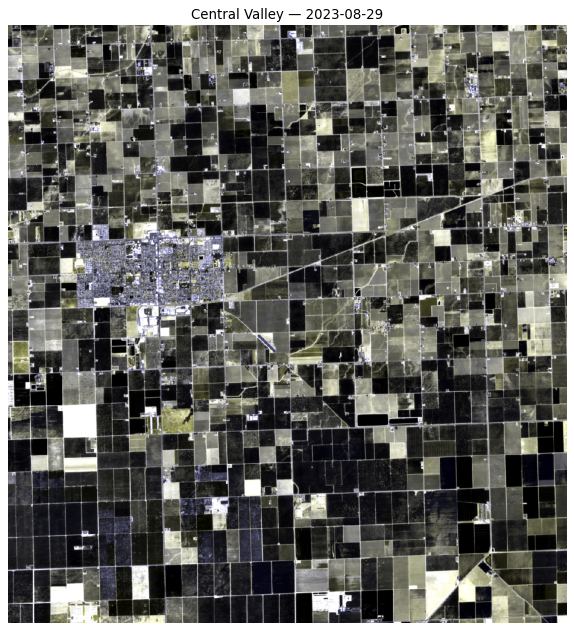

In [4]:
scene.plot_composite(["B04", "B04", "B02"], pmin=2, pmax=98,
                     title=f"Central Valley — {item.timestamp:%Y-%m-%d}")

## Greenness: NDVI

The field pattern should be immediately visible - a patchwork of dark green irrigated blocks against pale dry ground.

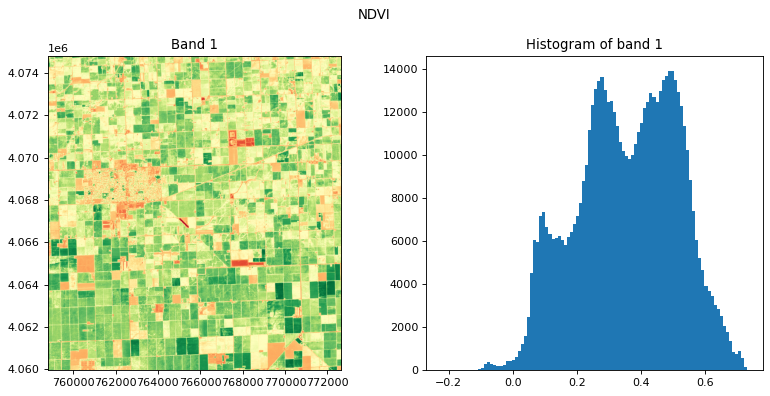

In [5]:
ndvi = scene.ndvi(red="B04", nir="B08")
ndvi.plot_raster_with_histogram(cmap="RdYlGn", bins=100, title="NDVI")

In [6]:
values = ndvi.get_band(1)

print(f"min    {np.nanmin(values):6.3f}")
for percentile in (10, 25, 50, 75, 90):
    print(f"p{percentile:<5d} {np.nanpercentile(values, percentile):6.3f}")
print(f"max    {np.nanmax(values):6.3f}")

print(f"\nactively growing (NDVI > 0.5): {np.nanmean(values > 0.5) * 100:5.1f}%")
print(f"bare or senescent (NDVI < 0.2): {np.nanmean(values < 0.2) * 100:5.1f}%")

min    -0.229
p10     0.129
p25     0.246
p50     0.365
p75     0.483
p90     0.551
max     0.732

actively growing (NDVI > 0.5):  20.9%
bare or senescent (NDVI < 0.2):  17.8%


A wide, flat distribution like this is the signature of a mixed agricultural landscape. A single-land-cover scene gives you one narrow peak.

## Moisture: NDMI

NDMI, `(NIR - SWIR1) / (NIR + SWIR1)`, responds to **water content in the canopy** rather than to how green it is. This is the index that shows stress early: a crop under water stress loses canopy moisture before it visibly browns, so NDMI falls while NDVI is still high.

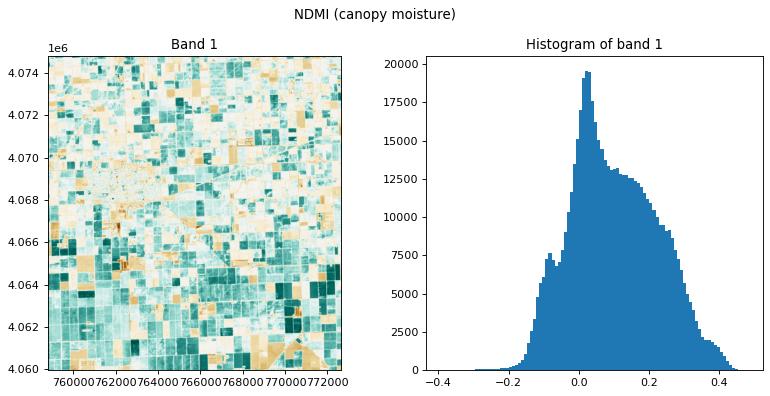

In [7]:
ndmi = scene.ndmi(swir="B11", nir="B08")
ndmi.plot_raster_with_histogram(cmap="BrBG", bins=100, title="NDMI (canopy moisture)")

## Greenness against moisture

Plotting the two against each other is where the diagnosis happens. Healthy irrigated crops sit high on both axes; bare soil sits low on both. The interesting pixels are the ones that are **green but dry** - high NDVI, low NDMI.

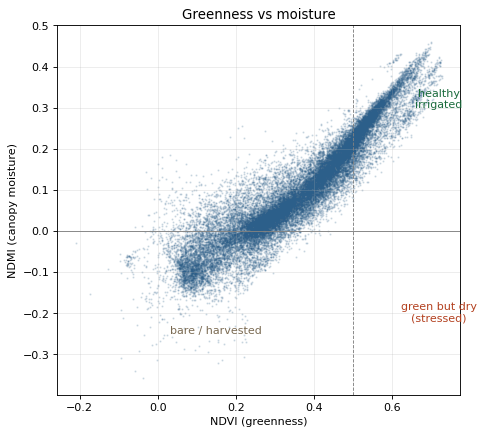

In [8]:
green = ndvi.get_band(1).ravel()
moist = ndmi.get_band(1).ravel()

sample = np.random.default_rng(0).choice(green.size, size=30000, replace=False)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(green[sample], moist[sample], s=1, alpha=0.15, color="#2c5f8a")
ax.axhline(0, color="grey", lw=0.8)
ax.axvline(0.5, color="grey", lw=0.8, ls="--")
ax.set_xlabel("NDVI (greenness)")
ax.set_ylabel("NDMI (canopy moisture)")
ax.set_title("Greenness vs moisture")
ax.text(0.72, 0.30, "healthy\nirrigated", ha="center", color="#1a6b3c")
ax.text(0.72, -0.22, "green but dry\n(stressed)", ha="center", color="#b3401f")
ax.text(0.15, -0.25, "bare / harvested", ha="center", color="#7a6a52")
ax.grid(alpha=0.25)
plt.show()

In [9]:
green2d = ndvi.get_band(1)
moist2d = ndmi.get_band(1)

healthy = (green2d > 0.5) & (moist2d > 0.1)
stressed = (green2d > 0.5) & (moist2d < 0.0)
bare = green2d < 0.2

pixel_area_km2 = abs(scene.get_transform().a * scene.get_transform().e) / 1e6

for label, mask in (("healthy irrigated", healthy), ("green but dry", stressed), ("bare / harvested", bare)):
    print(f"{label:20s} {mask.mean() * 100:5.1f}%   {mask.sum() * pixel_area_km2:7.2f} km^2")

healthy irrigated     20.9%     42.97 km^2
green but dry          0.0%      0.00 km^2
bare / harvested      17.8%     36.61 km^2


## Sparse cover: SAVI

NDVI has a known weakness - where vegetation is sparse, the soil underneath contributes most of the signal, and NDVI reports the soil's brightness as much as the plants. SAVI adds a soil-brightness term `L` to compensate: `0` behaves exactly like NDVI, `1` suits very sparse cover, `0.5` is the default middle.

In [10]:
savi = scene.savi(red="B04", nir="B08", soil_factor=0.5)

ndvi_values = ndvi.get_band(1)
savi_values = savi.get_band(1)

sparse = ndvi_values < 0.3
dense = ndvi_values > 0.6

print("where cover is sparse (NDVI < 0.3):")
print(f"  NDVI {np.nanmean(ndvi_values[sparse]):.3f}   SAVI {np.nanmean(savi_values[sparse]):.3f}"
      f"   difference {np.nanmean(savi_values[sparse] - ndvi_values[sparse]):+.3f}")
print("where cover is dense (NDVI > 0.6):")
print(f"  NDVI {np.nanmean(ndvi_values[dense]):.3f}   SAVI {np.nanmean(savi_values[dense]):.3f}"
      f"   difference {np.nanmean(savi_values[dense] - ndvi_values[dense]):+.3f}")

where cover is sparse (NDVI < 0.3):
  NDVI 0.189   SAVI 0.284   difference +0.095
where cover is dense (NDVI > 0.6):
  NDVI 0.643   SAVI 0.965   difference +0.321


## Saturation: EVI

NDVI's other weakness is at the top of its range - over dense canopy it saturates, and genuinely different biomass gives nearly the same number. EVI adds a blue-band correction for atmospheric scattering and a soil term, and keeps responding where NDVI has flattened.

EVI is the one index here whose formula is **not** scale-invariant: its constants assume reflectance in roughly `[0, 1]`, so divide the raw digital numbers by 10000 first.

EVI range: -29.659 to 32.140


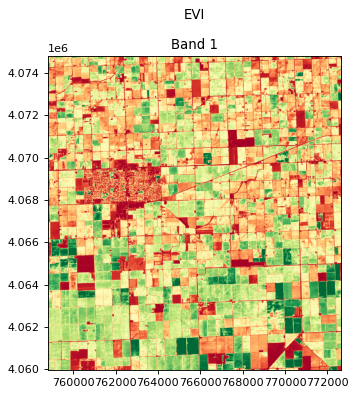

In [11]:
evi = scene.divide(10000).evi(red="B04", blue="B02", nir="B08")

evi_values = evi.get_band(1)
print(f"EVI range: {np.nanmin(evi_values):.3f} to {np.nanmax(evi_values):.3f}")

evi.plot_raster(cmap="RdYlGn", title="EVI")

In [12]:
# how much each index still varies over the densest canopy
top = ndvi_values > 0.7
print(f"over the densest canopy ({top.sum():,} pixels):")
print(f"  NDVI std {np.nanstd(ndvi_values[top]):.4f}")
print(f"  EVI  std {np.nanstd(evi_values[top]):.4f}   <- still discriminating")

over the densest canopy (6,540 pixels):
  NDVI std 0.0070
  EVI  std 0.0257   <- still discriminating


## Which index for which question

| question | index |
| --- | --- |
| how much green vegetation is there? | NDVI |
| is the canopy short of water? | NDMI |
| sparse cover over bright soil | SAVI |
| dense canopy where NDVI saturates | EVI |

The practical answer is rarely one index. NDVI tells you a field is green; NDMI tells you whether it is about to stop being green.

In [13]:
for ds in (scene, ndvi, ndmi, savi, evi):
    ds.close()
print("closed")

closed


## Next

- **[03_urban_footprint_land_cover](03_urban_footprint_land_cover.ipynb)** - combining indices into a classification